In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
FARS = pd.read_csv('FARSNO2.csv')
ENSO = pd.read_csv('ENSOMONTHLY.csv')


<Figure size 1500x600 with 0 Axes>

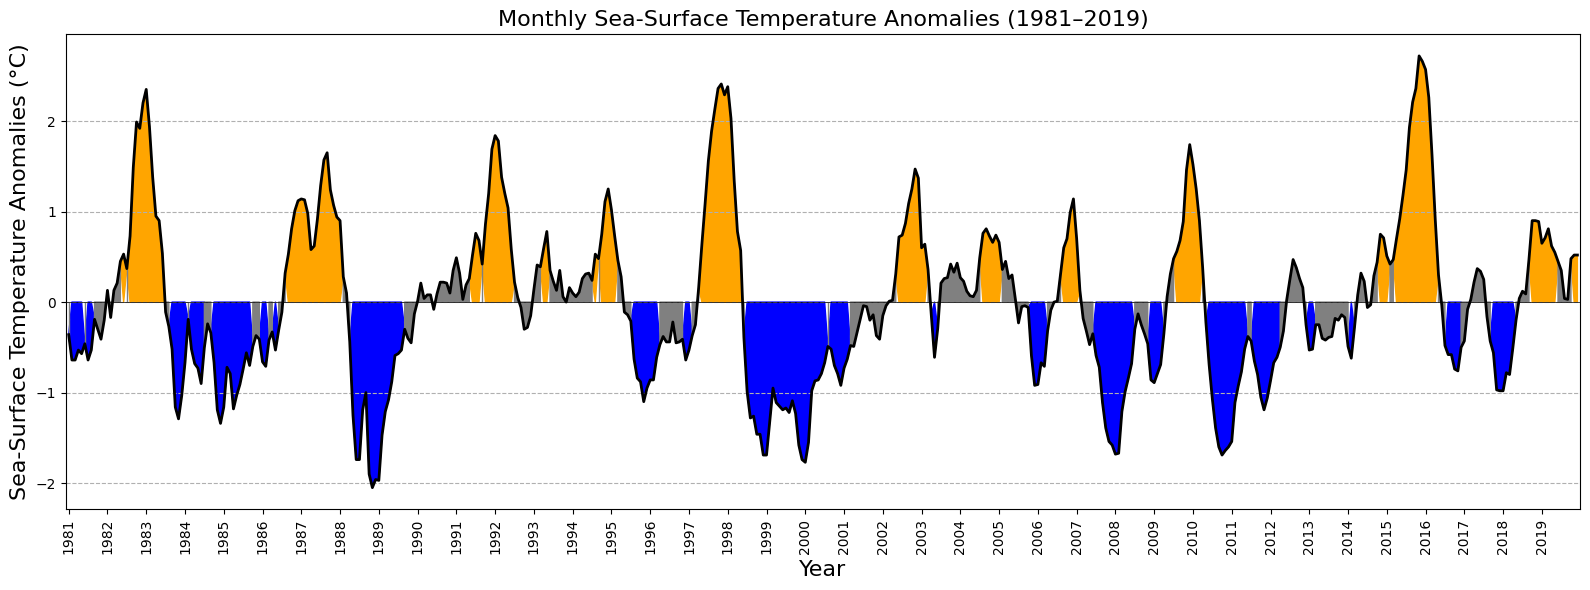

In [7]:
# Extracting the year column
years = ENSO['YEAR']
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
anomalies = ENSO[months]

plt.figure(figsize=(15, 6))

bar_num = len(years) * len(months)

# Extracting the monthly anomaly columns
anomaly_columns = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

# Filter the data for the years 1981 to 2019
mask = (ENSO['YEAR'] >= 1981) & (ENSO['YEAR'] <= 2019)
filtered_years = ENSO.loc[mask, 'YEAR']
filtered_anomalies = ENSO.loc[mask, anomaly_columns]

# Flatten filtered anomalies for plotting
line_values = filtered_anomalies.values.flatten()

bar_num = len(filtered_years) * len(anomaly_columns)

plt.figure(figsize=(16, 6))
plt.plot(range(len(line_values)), line_values, color='black', linewidth=2)

# Shade portions exceeding anomaly thresholds
plt.fill_between(range(len(line_values)), line_values, where=(line_values >= 0.5), color='orange', interpolate=True)
plt.fill_between(range(len(line_values)), line_values, where=(line_values <= -0.5), color='blue', interpolate=True)
plt.fill_between(range(len(line_values)), line_values, where=((line_values >= -0.5) & (line_values <= 0.5)), color='grey', interpolate=True)

# Customize plot appearance
plt.title('Monthly Sea-Surface Temperature Anomalies (1981–2019)', fontsize=16)
plt.xlabel('Year', fontsize=16)
plt.ylabel('Sea-Surface Temperature Anomalies (°C)', fontsize=16)
plt.xticks(range(0, len(line_values), len(anomaly_columns)), filtered_years, rotation=90)
plt.xlim(-0.9, bar_num - 0.2)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('AnomaliesByYear(1981-2019).png', facecolor="white")
plt.show()

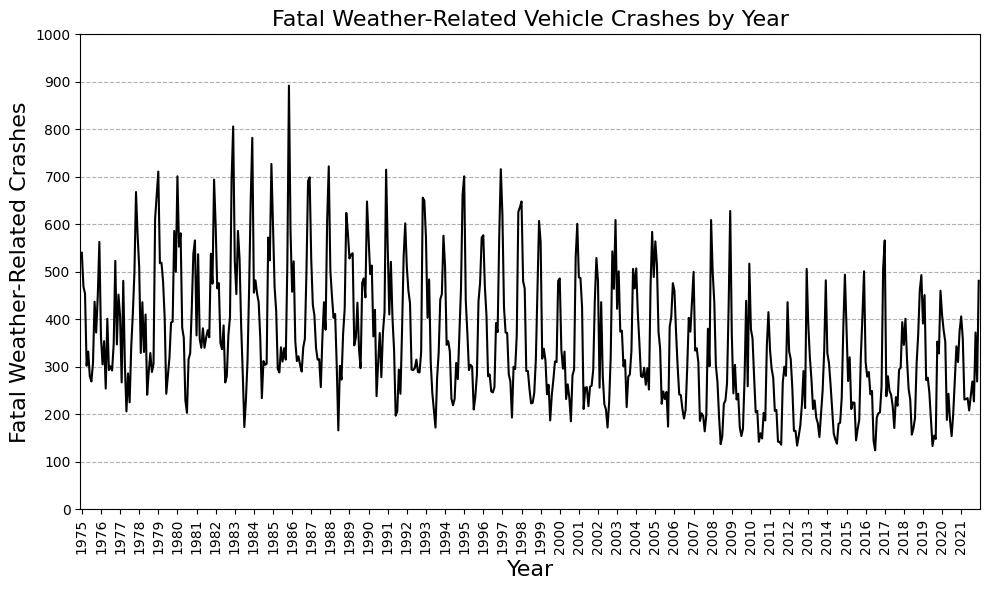

In [8]:
grouped_df = FARS.groupby(['YEAR','MONTH']).size().reset_index(name='Count')
grouped_df.sort_values(['YEAR','MONTH'], inplace = True)
# Get the unique years
unique_years = grouped_df['YEAR'].unique()

# Initialize a list to store the x-tick positions and labels
xtick_positions = []
xtick_labels = []

# Define the month names
month_names = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

# Iterate over the unique years
for year in unique_years:
    # Get the first month of each year
    first_month = grouped_df[grouped_df['YEAR'] == year]['MONTH'].iloc[0]
    
    # Get the index of the first month for the current year
    index = grouped_df[(grouped_df['YEAR'] == year) & (grouped_df['MONTH'] == first_month)].index[0]
    
    # Add the index to the x-tick positions
    xtick_positions.append(index)
    
    # Generate the x-tick label for the first month of each year
    xtick_labels.append(f"{year}")

# Plotting the line plot
plt.figure(figsize=(10, 6))

plt.plot(range(len(grouped_df)), grouped_df['Count'], color='black')

plt.title('Fatal Weather-Related Vehicle Crashes by Year',fontsize=16)
plt.xlabel('Year',fontsize=16)
plt.ylabel('Fatal Weather-Related Crashes',fontsize=16)

plt.xticks(xtick_positions, xtick_labels, rotation=90)
plt.xlim(-0.9, len(grouped_df) - 0.2)
plt.yticks(range(0, 1001, 100))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('FatalCrashesByYearLine2-1.png', facecolor="white")
plt.show()

In [ ]:
# Create the figure and the first subplot (temperature anomalies)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot #1: Monthly Sea-Surface Temperature Anomalies
font_size=16
ax1.plot(range(len(line_values)), line_values, color='black', linewidth=2, label='SST Anomaly')
ax1.set_title('Monthly Sea-Surface Temperature Anomalies and Fatal Weather-Related Crashes by Year',fontsize=font_size)
ax1.set_xlabel('Year', fontsize=font_size)
ax1.set_ylabel('Sea-Surface Temperature Anomalies (°C)', fontsize=font_size)
ax1.set_xticks(range(0, len(line_values), len(anomaly_columns)))
ax1.set_xticklabels(years, rotation=90)
ax1.set_xlim(-0.9, bar_num - 0.2)
ax1.set_ylim([-2.8, 3.5])
ax1.set_yticks([-3.6,-3.4,-3.2,-3.0,-2.8, -2.6, -2.4, -2.2, -2, -1.8, -1.6, -1.4, -1.2, -1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2, 2.2, 2.4, 2.6, 2.8,3.0,3.2,3.4,3.6])
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.grid(axis='y', linestyle='--')
ax1.legend(loc=[0.75,0.935])

# Share x axis with second subplot
ax2 = ax1.twinx()

# Plot #2: Fatal Weather-Related Vehicle Crashes by Year
ax2.plot(range(len(grouped_df)), grouped_df['Count'], color='black',linestyle='dashed', label='Fatal Weather-Related Crashes')
ax2.set_ylabel('Fatal Weather-Related Crashes', color='black', fontsize=font_size)
ax2.set_yticks(range(0, 1001, 100),color='red')
ax2.legend(loc=[0.75,0.885])
ax1.axhline(y=0.5, color='orange', linewidth=3.5, linestyle='--')
ax1.axhline(y=-0.5, color='blue', linewidth=3.5, linestyle='--')
ax1.annotate('SST > 0.5°C', xy=(2, 1), xytext=(1, 1.56), fontsize=16, color='orange')
ax1.annotate('SST < -0.5°C', xy=(2, 1), xytext=(1, -2.4), fontsize=16, color='blue' )

ax2_yticks = ax2.get_yticks()
ax2.set_yticklabels(ax2_yticks, rotation=90,color='black')


fig.tight_layout()

plt.savefig('CombinedPlotV2.png', facecolor="white")
plt.show()

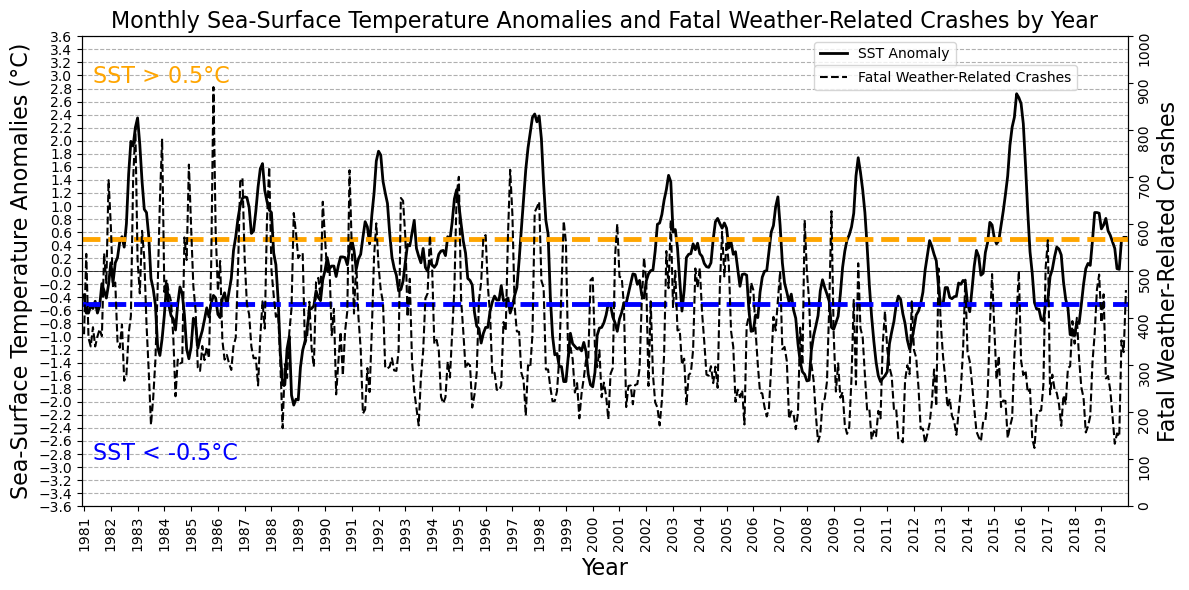

In [20]:
# Filter the data for the years 1981 to 2019
mask = (ENSO['YEAR'] >= 1981) & (ENSO['YEAR'] <= 2019)
filtered_years = ENSO.loc[mask, 'YEAR']
filtered_anomalies = ENSO.loc[mask, anomaly_columns]

# Flatten filtered anomalies for plotting
line_values = filtered_anomalies.values.flatten()

bar_num = len(filtered_years) * len(anomaly_columns)

# Create the figure and first subplot (temperature anomalies)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot #1: Monthly Sea-Surface Temperature Anomalies
font_size = 16
ax1.plot(range(len(line_values)), line_values, color='black', linewidth=2, label='SST Anomaly')
ax1.set_title('Monthly Sea-Surface Temperature Anomalies and Fatal Weather-Related Crashes by Year', fontsize=font_size)
ax1.set_xlabel('Year', fontsize=font_size)
ax1.set_ylabel('Sea-Surface Temperature Anomalies (°C)', fontsize=font_size)
ax1.set_xticks(range(0, len(line_values), len(anomaly_columns)))
ax1.set_xticklabels(filtered_years, rotation=90)
ax1.set_xlim(-0.9, bar_num - 0.2)
ax1.set_ylim([-2.8, 3.5])
ax1.set_yticks([-3.6, -3.4, -3.2, -3.0, -2.8, -2.6, -2.4, -2.2, -2, -1.8, -1.6, -1.4, -1.2, -1, 
                -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2, 2.2, 
                2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6])
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.grid(axis='y', linestyle='--')
ax1.legend(loc=[0.7, 0.935])

# Share x-axis with second subplot
ax2 = ax1.twinx()

# Ensure filtered crash data matches plot range
filtered_grouped_df = grouped_df[(grouped_df['YEAR'] >= 1981) & (grouped_df['YEAR'] <= 2019)]

# Plot #2: Fatal Weather-Related Vehicle Crashes by Year
ax2.plot(range(len(filtered_grouped_df)), filtered_grouped_df['Count'], color='black', linestyle='dashed', label='Fatal Weather-Related Crashes')
ax2.set_ylabel('Fatal Weather-Related Crashes', color='black', fontsize=font_size)
ax2.set_yticks(range(0, 1001, 100))
ax2.legend(loc=[0.7, 0.885])

# Additional plot elements
ax1.axhline(y=0.5, color='orange', linewidth=3.5, linestyle='--')
ax1.axhline(y=-0.5, color='blue', linewidth=3.5, linestyle='--')
ax1.annotate('SST > 0.5°C', xy=(2.11, 1), xytext=(4, 2.89), fontsize=16, color='orange')
ax1.annotate('SST < -0.5°C', xy=(2.11, 1), xytext=(4, -2.89), fontsize=16, color='blue')

ax2_yticks = ax2.get_yticks()
ax2.set_yticklabels(ax2_yticks, rotation=90, color='black')

fig.tight_layout()

plt.savefig('CombinedPlot_1981-2019.png', facecolor="white")
plt.show()

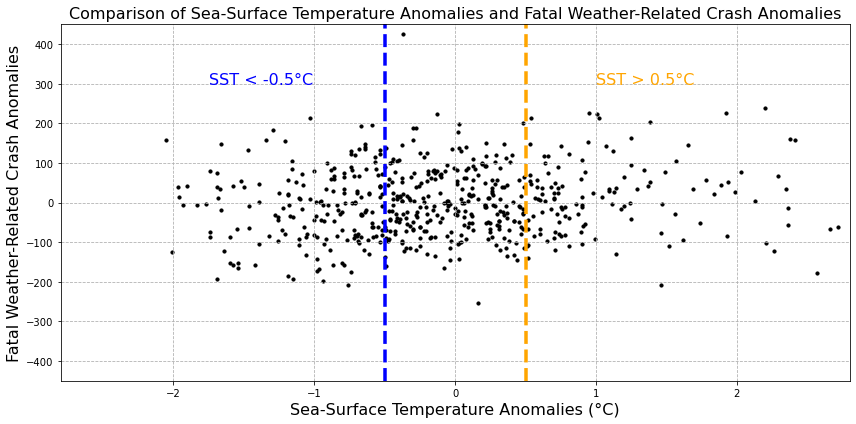

In [180]:
# Figure
fig, ax1 = plt.subplots(figsize=(12, 6))

# Monthly Sea-Surface Temperature Anomalies and Fatal Weather-Related Crashes
font_size = 16
ax1.scatter(line_values, anomaly, color='black', label='Anomalies vs Crashes',s=10)
ax1.set_title('Comparison of Sea-Surface Temperature Anomalies and Fatal Weather-Related Crash Anomalies', fontsize=font_size)
ax1.set_xlabel('Sea-Surface Temperature Anomalies (°C)', fontsize=font_size)
ax1.set_ylabel('Fatal Weather-Related Crash Anomalies', fontsize=font_size)
ax1.set_xlim(-2.8, 2.8)  # Adjust the limits based on your data range
ax1.set_ylim(-450, 450)  # Adjust the limits based on your data range
ax1.axvline(x=0.5, color='orange', linewidth=3.5, linestyle='--')
ax1.axvline(x=-0.5, color='blue', linewidth=3.5, linestyle='--')
ax1.annotate('SST > 0.5°C', xy=(2, 1), xytext=(1, 300), fontsize=16, color='orange')
ax1.annotate('SST < -0.5°C', xy=(2, 1), xytext=(-1.75, 300), fontsize=16, color='blue')
ax1.grid(axis='both', linestyle='--')



fig.tight_layout()
plt.savefig('CombinedScatterCrashAnomaliesV1.png', facecolor="white")
plt.show()

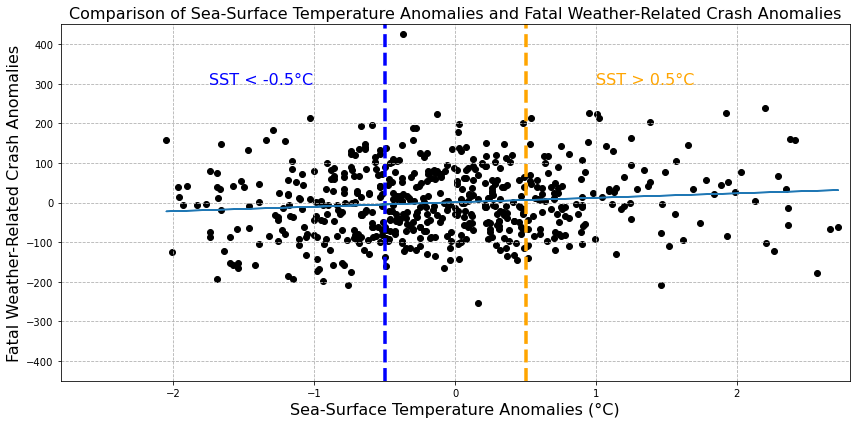

In [157]:
x = line_values
y= anomaly
res = stats.linregress(x,y)
res.rvalue**2

0.01227554413693926

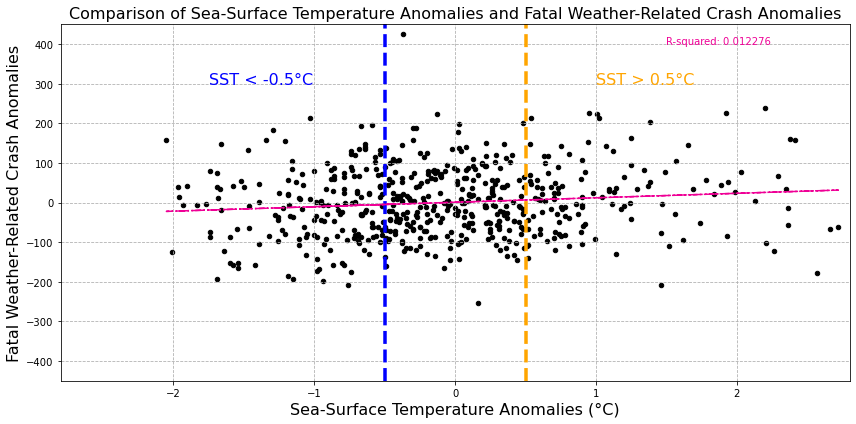

In [177]:
# Figure
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats
fig, ax1 = plt.subplots(figsize=(12, 6))

# Monthly Sea-Surface Temperature Anomalies and Fatal Weather-Related Crashes
font_size = 16
ax1.scatter(line_values, anomaly, color='black', label='Anomalies vs Crashes',s=10)
ax1.set_title('Comparison of Sea-Surface Temperature Anomalies and Fatal Weather-Related Crash Anomalies', fontsize=font_size)
ax1.set_xlabel('Sea-Surface Temperature Anomalies (°C)', fontsize=font_size)
ax1.set_ylabel('Fatal Weather-Related Crash Anomalies', fontsize=font_size)
ax1.set_xlim(-2.8, 2.8)  # Adjust the limits based on your data range
ax1.set_ylim(-450, 450)  # Adjust the limits based on your data range
ax1.axvline(x=0.5, color='orange', linewidth=3.5, linestyle='--')
ax1.axvline(x=-0.5, color='blue', linewidth=3.5, linestyle='--')
ax1.annotate('SST > 0.5°C', xy=(2, 1), xytext=(1, 300), fontsize=16, color='orange')
ax1.annotate('SST < -0.5°C', xy=(2, 1), xytext=(-1.75, 300), fontsize=16, color='blue')
ax1.grid(axis='both', linestyle='--')
m, b = np.polyfit(line_values, anomaly, 1)
plt.plot(line_values, m*line_values+b, linewidth=1.5, linestyle="dashdot",color='#EF0096')
ax1.annotate(f"R-squared: {res.rvalue**2:.6f}".format(r2_score(line_values, anomaly)), (1.5, 399.5), color='#EF0096')
x = line_values
y= anomaly
res = stats.linregress(x,y)
res


fig.tight_layout()
plt.savefig('CombinedScatterCrashAnomaliesV1.1.png', facecolor="white")
plt.show()